In [1]:
# !pip install -q pandas openpyxl python-docx scikit-learn matplotlib seaborn sentence-transformers joblib

#### Необходимые библиотеки

In [ ]:
import re, json, math, random, time as time_module, warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from docx import Document

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import Normalizer
from sklearn.base import clone

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

In [ ]:
BASE_DIR  = Path.cwd()
DATA_DIR  = BASE_DIR / "data"
OUT_DIR   = BASE_DIR / "system_output"
OUT_DIR.mkdir(exist_ok=True, parents=True)
MODELS_DIR = BASE_DIR / "models"
MODELS_DIR.mkdir(exist_ok=True)

GOLD_XLSX       = DATA_DIR / "gold_criteria_tests_001_009.xlsx"
SYNTH_CSV       = BASE_DIR / "output" / "generated_labels.csv"
SOURCE_DOCX_DIR = DATA_DIR
SYNTH_DOCX_DIR  = BASE_DIR / "output"
SUMMARY_XLSX    = OUT_DIR / "scoring_summary.xlsx"
ML_XLSX         = OUT_DIR / "ml_metrics.xlsx"

### Критерии, анонимизация

In [ ]:
import json

# переведены бизнес-названия -> criterion_XX
_private_json = os.getenv("CRIT_MAP_JSON", "crit_map_private.json")
with open(_private_json, "r", encoding="utf-8") as f:
    CRIT_MAP = json.load(f)

STAGE_ORDER = [
    "pre_analytics", "test_design", "monitoring",
    "tech_launch", "results_summary", "presentation",
]

CRITERIA_MAX = {
    "criterion_01": 2, "criterion_02": 1, "criterion_03": 1, "criterion_04": 2,
    "criterion_05": 1, "criterion_06": 1, "criterion_07": 3, "criterion_08": 1,
    "criterion_09": 2, "criterion_10": 1, "criterion_11": 3, "criterion_12": 3,
    "criterion_13": 2, "criterion_14": 1, "criterion_15": 1, "criterion_16": 2,
    "criterion_17": 2, "criterion_18": 1, "criterion_19": 2, "criterion_20": 2,
    "criterion_21": 1, "criterion_22": 2,
}

CRITERION_TO_STAGE = {
    "criterion_01": "pre_analytics",  "criterion_02": "pre_analytics",
    "criterion_03": "pre_analytics",  "criterion_04": "pre_analytics",
    "criterion_05": "test_design",    "criterion_06": "test_design",
    "criterion_07": "test_design",    "criterion_08": "test_design",
    "criterion_09": "monitoring",     "criterion_10": "monitoring",
    "criterion_11": "tech_launch",    "criterion_12": "tech_launch",
    "criterion_13": "results_summary","criterion_14": "results_summary",
    "criterion_15": "results_summary","criterion_16": "results_summary",
    "criterion_17": "results_summary","criterion_18": "results_summary",
    "criterion_19": "presentation",   "criterion_20": "presentation",
    "criterion_21": "presentation",   "criterion_22": "presentation",
}

ALL_CRITERIA = list(CRITERIA_MAX.keys())
print(f"✅ Config ready: {len(ALL_CRITERIA)} criteria | {len(STAGE_ORDER)} stages")

Criteria: 22 | Stages: 6


### Парсинг карточек

Карточка теста состоит из таблиц с заголовками строк (первая ячейка = метка).
Парсим через `python-docx`: обходим таблицы → строим словарь `{norm_label: value}`.
Отдельно извлекаем Доп. чек-лист


In [ ]:
def s(x):
    if x is None: return ""
    if isinstance(x, float):
        try:
            import math
            if math.isnan(x): return ""
        except Exception: pass
    return str(x)

def norm(text):
    t = s(text).lower().replace("ё","е")
    return re.sub(r"\s+", " ", t).strip()

def extract_testid_from_filename(path):
    m = re.match(r"^(\d{1,3})", Path(path).stem)
    return m.group(1).zfill(3) if m else None


def read_docx_tables(path):
    """Читает DOCX в raw_text + dict {norm_label: value} из таблиц."""
    doc = Document(path)
    fields = {}
    raw_lines = []

    for p in doc.paragraphs:
        t = p.text.strip()
        if t:
            raw_lines.append(t)

    for table in doc.tables:
        for row in table.rows:
            cells_text = [c.text.strip() for c in row.cells]
            # Удаляем дубли
            deduped = []
            for ct in cells_text:
                if not deduped or ct != deduped[-1]:
                    deduped.append(ct)
            raw_lines.append(" | ".join(deduped))
            if len(deduped) >= 2:
                label = norm(deduped[0])
                value = " ".join(deduped[1:]).strip()
                if label:
                    fields[label] = value

    return "\n".join(raw_lines), fields


def find_field(fields, raw_text, patterns, default=""):
    '''Ищет значение по паттернам в словаре таблиц'''
    for label, value in fields.items():
        for pat in patterns:
            if re.search(pat, label, re.IGNORECASE):
                return value
    for line in raw_text.splitlines():
        low = norm(line)
        for pat in patterns:
            if re.search(pat, low, re.IGNORECASE):
                if ":" in line:
                    val = line.split(":", 1)[1].strip()
                    if val: return val
                parts = line.split("|")
                if len(parts) >= 2 and parts[1].strip():
                    return parts[1].strip()
    return default


def find_checklist_item(fields, raw_text, item_patterns):
    ''' (status, owner) из чек-листа аналитика/ответственного'''
    for label, value in fields.items():
        for pat in item_patterns:
            if re.search(pat, label, re.IGNORECASE):
                parts = value.split()
                status = parts[0] if parts else ""
                owner  = " ".join(parts[1:]) if len(parts) > 1 else ""
                return status, owner
    lines = raw_text.splitlines()
    for i, line in enumerate(lines):
        low = norm(line)
        for pat in item_patterns:
            if re.search(pat, low, re.IGNORECASE):
                rest = line.split("|")
                if len(rest) >= 3:
                    return rest[1].strip(), rest[2].strip()
                if i + 1 < len(lines):
                    nxt = lines[i+1].strip()
                    if nxt: return nxt, ""
    return "", ""


def parse_dates_diff(fields, raw_text, plan_pats, fact_pats):
    '''Возвращает разницу в днях'''
    import datetime
    def parse_dt(v):
        for fmt in ("%d.%m.%Y", "%Y-%m-%d", "%d/%m/%Y"):
            try: return datetime.datetime.strptime(s(v).strip()[:10], fmt)
            except Exception: pass
        return None
    plan = find_field(fields, raw_text, plan_pats)
    fact = find_field(fields, raw_text, fact_pats)
    d_plan, d_fact = parse_dt(plan), parse_dt(fact)
    if d_plan and d_fact:
        return abs((d_fact - d_plan).days)
    return None


def parse_ttm_impl(fields, raw_text):
    '''Дней от проработки до запуска'''
    val = find_field(fields, raw_text, [
        r"время от.*(проработки|старта).*до запуска",
        r"time to market.*реализ", r"ttm.*реализ",
        r"от старта проработки",
    ])
    m = re.search(r"(-?\d+)", s(val))
    return int(m.group(1)) if m else None

In [ ]:
# набор регулярок
with open(os.getenv("REGEX_PATTERNS_JSON")) as f:
    globals().update(json.load(f))

In [ ]:
def parse_card_from_docx(path):
    '''Парсит одну DOCX-карточку в dict с полями для скоринга (публичная версия)'''
    raw_text, fields = read_docx_tables(path)
    test_id = extract_testid_from_filename(path)

    card = {"test_id": test_id, "docx_path": str(path), "raw_text": raw_text}

    card["criterion_01"] = find_field(fields, raw_text, [REGEX_C01])
    card["criterion_02"] = find_field(fields, raw_text, [REGEX_C02])
    card["criterion_03"] = find_field(fields, raw_text, [REGEX_C03])
    card["criterion_04"] = find_field(fields, raw_text, [REGEX_C04])
    card["criterion_05"] = find_field(fields, raw_text, [REGEX_C05])

    card["criterion_06"], card["criterion_06_owner"] = find_checklist_item(fields, raw_text, [REGEX_C06])
    card["criterion_07"], card["criterion_07_owner"] = find_checklist_item(fields, raw_text, [REGEX_C07])

    card["criterion_08"] = find_field(fields, raw_text, [REGEX_C08])
    card["criterion_09"] = find_field(fields, raw_text, [REGEX_C09])
    card["criterion_10"] = find_field(fields, raw_text, [REGEX_C10])

    card["criterion_11"] = parse_ttm_impl(fields, raw_text)

    card["criterion_12"] = find_field(fields, raw_text, [REGEX_C12])
    card["criterion_13"] = find_field(fields, raw_text, [REGEX_C13])
    card["criterion_14"] = find_field(fields, raw_text, [REGEX_C14])
    card["criterion_15"] = find_field(fields, raw_text, [REGEX_C15])
    card["criterion_16"] = find_field(fields, raw_text, [REGEX_C16])

    card["criterion_17"] = parse_dates_diff(
        fields, raw_text,
        plan_pats=[REGEX_C17_PLAN],
        fact_pats=[REGEX_C17_FACT],
    )

    card["criterion_18"], card["criterion_18_owner"] = find_checklist_item(fields, raw_text, [REGEX_C18])
    card["criterion_19"] = find_field(fields, raw_text, [REGEX_C19])
    card["criterion_20"] = find_field(fields, raw_text, [REGEX_C20])
    card["criterion_21"] = find_field(fields, raw_text, [REGEX_C21])
    card["criterion_22"], card["criterion_22_owner"] = find_checklist_item(fields, raw_text, [REGEX_C22])

    return card

## Загрузка данных

In [ ]:
import os
import json
import pandas as pd
from pathlib import Path

# маппинг бизнес-названий и criterion_XX
with open(os.getenv("CRIT_MAP_JSON", "crit_map_private.json"), encoding="utf-8") as f:
    CRIT_MAP = json.load(f)

# Анонимные текстовые столбцы, в соответствии с parse_card_from_docx
TEXT_COLS = [f"criterion_{i:02d}" for i in range(1, 23)]
TEXT_COLS += [
    "criterion_06_owner", "criterion_07_owner",
    "criterion_18_owner", "criterion_22_owner",
    "raw_text"
]

def read_labels(path, fmt="excel", dataset_tag=None):
    """Читает разметку, анонимизирует критерии через CRIT_MAP."""
    df = pd.read_excel(path) if fmt == "excel" else pd.read_csv(path)
    df.columns = [c.strip().lower() for c in df.columns]
    df = df.rename(columns={
        "testid": "test_id", "maxscore": "max_score",
        "scorestagetotal": "score_stage_total", "scoretesttotal": "score_test_total",
    })
    cols = [c for c in ["test_id", "stage", "criterion", "max_score", "score",
                         "score_stage_total", "score_test_total"] if c in df.columns]
    df = df[cols].copy()
    df["test_id"] = df["test_id"].astype(str).str.zfill(3)
    df["criterion"] = df["criterion"].map(lambda x: CRIT_MAP.get(x, x))
    if dataset_tag:
        df["dataset"] = dataset_tag
    return df

def collect_docx_cards(docx_dirs):
    """Парсит все DOCX из списка папок."""
    cards, seen = [], set()
    for d in docx_dirs:
        for p in sorted(Path(d).glob("*.docx")):
            key = str(p)
            if key in seen:
                continue
            seen.add(key)
            try:
                cards.append(parse_card_from_docx(p))
            except Exception as e:
                print(f"  Warning: {p.name}: {e}")
    return pd.DataFrame(cards)

In [ ]:
gold_df  = read_labels(GOLD_XLSX, fmt="excel", dataset_tag="gold")
synth_df = read_labels(SYNTH_CSV, fmt="csv",   dataset_tag="synthetic")

all_labels = pd.concat([gold_df, synth_df], ignore_index=True, sort=False)

cards_df = collect_docx_cards([SOURCE_DOCX_DIR, SYNTH_DOCX_DIR])
for col in TEXT_COLS:
    if col not in cards_df.columns:
        cards_df[col] = ""
    cards_df[col] = cards_df[col].fillna("").astype(str)
cards_df["full_text"] = cards_df[TEXT_COLS].agg(" ".join, axis=1)

card_text_map = dict(zip(cards_df["test_id"], cards_df["full_text"]))
card_raw_map  = dict(zip(cards_df["test_id"], cards_df["raw_text"]))
all_labels["full_text"] = all_labels["test_id"].map(card_text_map).fillna("")
all_labels["raw_text"]  = all_labels["test_id"].map(card_raw_map).fillna("")

print(f"Gold    : {len(gold_df):,} rows | {gold_df['test_id'].nunique()} tests")
print(f"Synth   : {len(synth_df):,} rows | {synth_df['test_id'].nunique()} tests")
print(f"All     : {len(all_labels):,} rows")
print(f"Cards   : {len(cards_df)} parsed")
print(f"Criteria: {all_labels['criterion'].unique()[:4].tolist()} ...")

Gold    : 198 rows | 9 tests
Synth   : 5,940 rows | 270 tests
All     : 6,138 rows
Cards   : 279 parsed
Criteria: ['criterion_01', 'criterion_02', 'criterion_03', 'criterion_04'] ...


### Грубые правила и определение метрик

In [ ]:
def contains_link(text):
    return bool(re.search(
        r"https?://|//pages|//notes|//display|hippo|helicopter|wiki",
        s(text), re.I))

def contains_done_loose(text):
    return bool(re.search(r"\b(done|да|yes|выполнено|заполнено)\b", s(text), re.I))

def count_bugs(text):
    t = norm(text)
    if re.search(r"(отсутствуют|не обнаружены|нет|\bнет\b|^0$|не было)", t):
        return 0
    nums = re.findall(r"\d+", t)
    return int(nums[0]) if nums else None

def has_numeric_values(text):
    return bool(re.search(r"\d+[.,]?\d*", s(text)))

def scores_to_long(test_id, score_dict, source, source_docx=None):
    total = sum(score_dict.values())
    return [{
        "test_id": test_id, "source": source, "docx_path": source_docx,
        "stage": CRITERION_TO_STAGE[crit], "criterion": crit,
        "max_score": CRITERIA_MAX[crit], "score": score,
        "score_test_total": total,
    } for crit, score in score_dict.items()]

def compute_metrics(y_true, y_pred):
    y_t = np.array(y_true, dtype=float)
    y_p = np.array(y_pred, dtype=float)
    mask = ~(np.isnan(y_t) | np.isnan(y_p))
    y_t, y_p = y_t[mask], y_p[mask]
    if len(y_t) == 0:
        return {"mae": np.nan, "rmse": np.nan, "acc1": np.nan, "n": 0}
    mae  = mean_absolute_error(y_t, y_p)
    rmse = float(np.sqrt(np.mean((y_t - y_p)**2)))
    acc1 = float(np.mean(y_t == y_p))
    return {"mae": round(mae,4), "rmse": round(rmse,4), "acc1": round(acc1,4), "n": len(y_t)}

def evaluate_predictions(true_df, pred_df, pred_col, err_col):
    merged = true_df.merge(
        pred_df[["test_id","stage","criterion","score"]].rename(columns={"score": pred_col}),
        on=["test_id","stage","criterion"], how="left"
    )
    merged[err_col] = (merged["score"] - merged[pred_col]).abs()
    return merged

def metrics_by(eval_df, true_col, pred_col, by):
    rows = []
    for g, gdf in eval_df.groupby(by):
        m = compute_metrics(gdf[true_col], gdf[pred_col])
        m[by] = g
        rows.append(m)
    return pd.DataFrame(rows).set_index(by)

### Подход 1: Rule-based скоринг

Детерминированные правила по структурированным полям карточки.
Каждое поле проверяется на наличие/тип контента.


In [ ]:
def rule_score_card(card):
    '''Скоринг карточки по правилам. Возвращает {criterion_XX: score}'''
    y = {}

    # pre_analytics
    y["criterion_01"] = 2 if contains_link(card.get("criterion_01", "")) else 0
    y["criterion_02"] = 1 if s(card.get("criterion_02", "")).strip() else 0
    y["criterion_03"] = 1 if s(card.get("criterion_03", "")).strip() else 0

    eff_text = s(card.get("criterion_14", "")) + " " + s(card.get("criterion_21", ""))
    if re.search(r"\d+.*млн|\d+.*руб|\d+[.,]\d+%", norm(eff_text)):
        y["criterion_04"] = 2
    elif s(card.get("criterion_14", "")).strip() or s(card.get("criterion_16", "")).strip():
        y["criterion_04"] = 1
    else:
        y["criterion_04"] = 0

    # test_design
    y["criterion_05"] = 1
    y["criterion_06"] = 1 if contains_done_loose(card.get("criterion_06", "")) else 0

    ee_ok    = contains_done_loose(card.get("criterion_07", ""))
    ee_owner = bool(s(card.get("criterion_07_owner", "")).strip())
    y["criterion_07"] = 3 if (ee_ok and ee_owner) else (1 if ee_ok else 0)

    conflicts = norm(card.get("criterion_08", ""))
    y["criterion_08"] = 1 if re.search(r"отсутствуют|нет|no conflict", conflicts) else 0

    # monitoring
    y["criterion_09"] = 2 if contains_link(card.get("criterion_09", "")) else 0
    y["criterion_10"] = 1 if s(card.get("criterion_10", "")).strip() else 0

    # tech_launch
    ttm_i = card.get("criterion_11")
    if ttm_i is None:   y["criterion_11"] = 0
    elif ttm_i <= 30:   y["criterion_11"] = 3
    elif ttm_i <= 60:   y["criterion_11"] = 2
    elif ttm_i <= 90:   y["criterion_11"] = 1
    else:               y["criterion_11"] = 0

    bugs_n = count_bugs(card.get("criterion_10", ""))
    if bugs_n is None:  y["criterion_12"] = 0
    elif bugs_n == 0:   y["criterion_12"] = 3
    elif bugs_n == 1:   y["criterion_12"] = 2
    elif bugs_n == 2:   y["criterion_12"] = 1
    else:               y["criterion_12"] = 0

    # results_summary
    y["criterion_13"] = 2 if s(card.get("criterion_13", "")).strip() else 0
    y["criterion_14"] = 1 if has_numeric_values(card.get("criterion_14", "")) else 0
    y["criterion_15"] = 1 if contains_link(card.get("criterion_15", "")) else 0

    result_fields = ["criterion_14", "criterion_19", "criterion_20"]
    filled = sum(1 for f in result_fields if s(card.get(f, "")).strip())
    y["criterion_16"] = 2 if filled >= 2 else (1 if filled >= 1 else 0)

    ttm_r = card.get("criterion_17")
    if ttm_r is None:  y["criterion_17"] = 0
    elif ttm_r <= 30:  y["criterion_17"] = 2
    elif ttm_r <= 60:  y["criterion_17"] = 1
    else:              y["criterion_17"] = 0

    y["criterion_18"] = 1 if contains_done_loose(card.get("criterion_18", "")) else 0

    # presentation
    mats = s(card.get("criterion_19", ""))
    y["criterion_19"] = 2 if contains_link(mats) else (1 if mats.strip() else 0)
    y["criterion_20"] = 2 if contains_link(card.get("criterion_20", "")) else 0

    biz_filled = sum(1 for f in ["criterion_21", "criterion_04", "criterion_16"]
                     if s(card.get(f, "")).strip())
    y["criterion_21"] = 1 if biz_filled >= 2 else 0

    biz_ok    = contains_done_loose(card.get("criterion_22", ""))
    biz_owner = bool(s(card.get("criterion_22_owner", "")).strip())
    y["criterion_22"] = 2 if (biz_ok and biz_owner) else (1 if biz_ok else 0)

    return y

In [ ]:
t0 = time_module.time()
rule_rows = []
for _, row in cards_df.iterrows():
    pred = rule_score_card(row.to_dict())
    rule_rows.extend(scores_to_long(row["test_id"], pred, "rule_based", row.get("docx_path")))

rule_pred_df = pd.DataFrame(rule_rows)
RULE_INFER_TIME = time_module.time() - t0

rule_eval = evaluate_predictions(all_labels, rule_pred_df, "rule_score", "abs_error_rule")
m_rule = compute_metrics(rule_eval["score"], rule_eval["rule_score"])
print(f"Rule-based | MAE={m_rule['mae']:.4f} | RMSE={m_rule['rmse']:.4f} | Acc@1={m_rule['acc1']:.4f} | Time={RULE_INFER_TIME:.3f}s")

Rule-based | MAE=0.4464 | RMSE=0.9078 | Acc@1=0.7033 | Time=0.093s


### Подход 2: TF-IDF + ML (несколько моделей)
  
Train/test split 2:1 по test_id, тесты не должны пересечься.  
Модели: LogReg, LinearSVC, RidgeClassifier, MultinomialNB, RandomForest, GradBoost, KNN.


In [ ]:
np.random.seed(42)
all_test_ids = sorted(all_labels["test_id"].unique())
np.random.shuffle(all_test_ids)
split_idx = int(len(all_test_ids) * (2/3))
train_ids = set(all_test_ids[:split_idx])
test_ids  = set(all_test_ids[split_idx:])

train_df = all_labels[all_labels["test_id"].isin(train_ids)].copy()
test_df  = all_labels[all_labels["test_id"].isin(test_ids)].copy()

print(f"Train: {len(train_ids)} tests, {len(train_df)} rows")
print(f"Test : {len(test_ids)} tests,  {len(test_df)} rows")
print(f"Overlap: {len(train_ids & test_ids)}") # пересечение

Train: 186 tests, 4092 rows
Test : 93 tests,  2046 rows
Overlap: 0


In [ ]:
tfidf   = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), lowercase=True)
X_train = tfidf.fit_transform(train_df["raw_text"].fillna(""))
X_test  = tfidf.transform(test_df["raw_text"].fillna(""))
print(f"TF-IDF: {X_train.shape[1]} features | train {X_train.shape[0]} | test {X_test.shape[0]}")

TF-IDF: 4652 features | train 4092 | test 2046


In [ ]:
ML_MODELS = {
    "logreg":         LogisticRegression(max_iter=1000, n_jobs=-1),
    "linearsvc":      make_pipeline(Normalizer(copy=False), LinearSVC()),
    "ridge":          make_pipeline(Normalizer(copy=False), RidgeClassifier()),
    "multinb":        MultinomialNB(),
    "random_forest":  make_pipeline(Normalizer(copy=False),
                          RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)),
    "grad_boost":     make_pipeline(Normalizer(copy=False),
                          GradientBoostingClassifier(n_estimators=50, random_state=42)),
    "knn":            make_pipeline(Normalizer(copy=False), KNeighborsClassifier(n_neighbors=5)),
}

pred_cols      = {m: f"ml_{m}" for m in ML_MODELS}
infer_times    = {m: 0.0 for m in ML_MODELS}
trained_models = {m: {} for m in ML_MODELS}
ml_metrics_rows = []

for col in pred_cols.values():
    test_df[col] = np.nan

for crit in sorted(all_labels["criterion"].unique()):
    tr_mask = train_df["criterion"] == crit
    te_mask = test_df["criterion"]  == crit
    y_tr = train_df.loc[tr_mask, "score"].values
    y_te = test_df.loc[te_mask,  "score"].values
    if len(y_tr) == 0 or len(np.unique(y_tr)) < 2: continue

    idx_tr = np.where(tr_mask.values)[0]
    idx_te = np.where(te_mask.values)[0]
    X_tr, X_te = X_train[idx_tr], X_test[idx_te]

    for mname, mproto in ML_MODELS.items():
        clf = clone(mproto)
        clf.fit(X_tr, y_tr)
        trained_models[mname][crit] = clf
        t0 = time_module.time()
        y_pred = clf.predict(X_te)
        infer_times[mname] += time_module.time() - t0
        test_df.loc[te_mask, pred_cols[mname]] = y_pred
        m = compute_metrics(y_te, y_pred)
        m.update({"model": mname, "criterion": crit})
        ml_metrics_rows.append(m)

ml_metrics = pd.DataFrame(ml_metrics_rows)
summary_ml = (
    ml_metrics.groupby("model", as_index=False)
    .agg(mae=("mae","mean"), rmse=("rmse","mean"), acc1=("acc1","mean"))
    .sort_values("mae").reset_index(drop=True)
)
summary_ml["infer_time_s"] = summary_ml["model"].map(infer_times)
best_model_name = summary_ml.iloc[0]["model"]
print(f"Лучшая ML-модель (MAE): {best_model_name}")
display(summary_ml)

Лучшая ML-модель (MAE): grad_boost


,model,mae,rmse,acc1,infer_time_s
0,grad_boost,0.030729,0.167167,0.978481,0.056254
1,linearsvc,0.050690,0.235510,0.963643,0.036757
2,ridge,0.054786,0.244048,0.960571,0.035285
3,knn,0.069643,0.300790,0.952371,0.461329
4,random_forest,0.073214,0.271433,0.945729,0.863713
5,multinb,0.078862,0.325262,0.945200,0.014052
6,logreg,0.084481,0.343586,0.942648,0.015640


### Подход 3: Гибрид Rule-based + ML

Структурные поля проверяются правилами.  
Семантические поля (качество описания, выводов) - лучшей TF-IDF ML-моделью.


In [ ]:
HARD_CRITERIA = {
    "criterion_01","criterion_02","criterion_03",
    "criterion_06","criterion_08","criterion_09",
    "criterion_10","criterion_11","criterion_12",
    "criterion_15","criterion_18","criterion_20",
}
SOFT_CRITERIA = [c for c in ALL_CRITERIA if c not in HARD_CRITERIA]

best_per_crit = (
    ml_metrics
    .sort_values(["criterion","mae","acc1"], ascending=[True,True,False])
    .groupby("criterion", as_index=False).first()
)
crit_to_best = dict(zip(best_per_crit["criterion"], best_per_crit["model"]))
print("Hard criteria:", len(HARD_CRITERIA))
print("Soft criteria:", len(SOFT_CRITERIA))

Hard criteria: 12
Soft criteria: 10


In [ ]:
t0 = time_module.time()
hybrid_rows = []
X_all = tfidf.transform(cards_df["raw_text"].fillna(""))

for i, (_, row) in enumerate(cards_df.iterrows()):
    rule_p = rule_score_card(row.to_dict())
    preds  = {c: rule_p[c] for c in HARD_CRITERIA}
    x_row  = X_all[i]
    for crit in SOFT_CRITERIA:
        best_m = crit_to_best.get(crit, best_model_name)
        clf = trained_models.get(best_m, {}).get(crit)
        preds[crit] = int(clf.predict(x_row)[0]) if clf else rule_p.get(crit, 0)
    hybrid_rows.extend(scores_to_long(row["test_id"], preds, "hybrid_rule_ml", row.get("docx_path")))

hybrid_pred_df = pd.DataFrame(hybrid_rows)
HYBRID_ML_INFER_TIME = time_module.time() - t0

hybrid_eval = evaluate_predictions(all_labels, hybrid_pred_df, "hybrid_score", "abs_error_hybrid")
m_hybrid = compute_metrics(hybrid_eval["score"], hybrid_eval["hybrid_score"])
print(f"Hybrid Rule+ML | MAE={m_hybrid['mae']:.4f} | RMSE={m_hybrid['rmse']:.4f} | Acc@1={m_hybrid['acc1']:.4f} | Time={HYBRID_ML_INFER_TIME:.3f}s")

Hybrid Rule+ML | MAE=0.1318 | RMSE=0.4575 | Acc@1=0.9058 | Time=3.436s


### Подход 4: Гибрид Rule-based + Retrieval (Sentence Transformers)

k-NN по sentence embeddings проверяет критерии, которые правила оценивали бы грубо;

Индекс строится по карточкам из train split.


In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

embedder = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
print("Sentence Transformer loaded")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Sentence Transformer loaded


In [ ]:
# Строим индекс по train-карточкам
retr_cards = cards_df[cards_df["test_id"].isin(train_ids)].reset_index(drop=True)
retr_embs  = embedder.encode(
    retr_cards["full_text"].fillna("").tolist(),
    normalize_embeddings=True, show_progress_bar=True
)

# Лукап оценок для train карточек
def build_score_lookup(df):
    return {
        crit: dict(zip(
            df[df["criterion"]==crit]["test_id"],
            df[df["criterion"]==crit]["score"]
        )) for crit in ALL_CRITERIA
    }

retr_lookup = build_score_lookup(all_labels[all_labels["test_id"].isin(train_ids)])
print("Retrieval index:", retr_embs.shape)

Batches:   0%|          | 0/6 [00:00<?, ?it/s]

Retrieval index: (186, 384)


In [ ]:
def retrieval_predict(card_row, k=3):
    text  = s(card_row.get("full_text",""))
    t_id  = card_row.get("test_id")
    q_emb = embedder.encode([text], normalize_embeddings=True, show_progress_bar=False)
    sims  = cosine_similarity(q_emb, retr_embs)[0]
    neigh = retr_cards.copy()
    neigh["sim"] = sims
    if t_id: neigh = neigh[neigh["test_id"] != t_id]
    top_k = neigh.nlargest(k, "sim")["test_id"].tolist()

    rule_p = rule_score_card(card_row.to_dict() if hasattr(card_row,"to_dict") else card_row)
    preds  = {c: rule_p[c] for c in HARD_CRITERIA}
    for crit in SOFT_CRITERIA:
        scores_n = [retr_lookup.get(crit,{}).get(nid,0) for nid in top_k]
        val = int(round(np.mean(scores_n))) if scores_n else 0
        preds[crit] = max(0, min(val, CRITERIA_MAX[crit]))
    return preds


t0 = time_module.time()
retr_rows = []
for _, row in cards_df.iterrows():
    pred = retrieval_predict(row)
    retr_rows.extend(scores_to_long(row["test_id"], pred, "hybrid_rule_retr", row.get("docx_path")))

retrieval_pred_df = pd.DataFrame(retr_rows)
RETR_INFER_TIME = time_module.time() - t0

retr_eval = evaluate_predictions(all_labels, retrieval_pred_df, "retr_score", "abs_error_retr")
m_retr = compute_metrics(retr_eval["score"], retr_eval["retr_score"])
print(f"Hybrid Rule+Retr | MAE={m_retr['mae']:.4f} | RMSE={m_retr['rmse']:.4f} | Acc@1={m_retr['acc1']:.4f} | Time={RETR_INFER_TIME:.3f}s")

Hybrid Rule+Retr | MAE=0.1812 | RMSE=0.5278 | Acc@1=0.8659 | Time=43.937s


### Сводная оценка всех подходов

Оцениваем на всём наборе тестов.  
Метрики: MAE, RMSE, Acc@1, время инференса.
В разрезах по этапам и по критериям.

In [ ]:
# TF-IDF best model — применяем ко всем данным (обученные на train, predict на all)
X_all_labels = tfidf.transform(all_labels["raw_text"].fillna(""))
all_labels = all_labels.copy()
all_labels["tfidf_score"] = np.nan

t0 = time_module.time()
for crit in sorted(all_labels["criterion"].unique()):
    mask = all_labels["criterion"] == crit
    clf  = trained_models.get(best_model_name, {}).get(crit)
    if clf:
        idx = np.where(mask.values)[0]
        all_labels.loc[mask, "tfidf_score"] = clf.predict(X_all_labels[idx])
TFIDF_ALL_INFER_TIME = time_module.time() - t0

m_tfidf = compute_metrics(all_labels["score"], all_labels["tfidf_score"])
print(f"TF-IDF ({best_model_name}) | MAE={m_tfidf['mae']:.4f} | RMSE={m_tfidf['rmse']:.4f} | Acc@1={m_tfidf['acc1']:.4f} | Time={TFIDF_ALL_INFER_TIME:.3f}s")

TF-IDF (grad_boost) | MAE=0.0102 | RMSE=0.1319 | Acc@1=0.9928 | Time=0.174s


In [ ]:
# общая сводка
global_summary = pd.DataFrame([
    {"system": "rule_based",           **m_rule,   "infer_time_s": RULE_INFER_TIME},
    {"system": "hybrid_rule_ml",       **m_hybrid, "infer_time_s": HYBRID_ML_INFER_TIME},
    {"system": "hybrid_rule_retr",     **m_retr,   "infer_time_s": RETR_INFER_TIME},
    {"system": f"tfidf_{best_model_name}", **m_tfidf,"infer_time_s": TFIDF_ALL_INFER_TIME},
]).sort_values("mae").reset_index(drop=True)

print("=" * 65)
print("ИТОГОВОЕ СРАВНЕНИЕ (all data: gold + synthetic)")
print("=" * 65)
display(global_summary[["system","mae","rmse","acc1","infer_time_s","n"]])

ИТОГОВОЕ СРАВНЕНИЕ (all data: gold + synthetic)


,system,mae,rmse,acc1,infer_time_s,n
0,tfidf_grad_boost,0.0102,0.1319,0.9928,0.173647,5859
1,hybrid_rule_ml,0.1318,0.4575,0.9058,3.436253,6138
2,hybrid_rule_retr,0.1812,0.5278,0.8659,43.936635,6138
3,rule_based,0.4464,0.9078,0.7033,0.093307,6138


In [ ]:
# по критериям
tfidf_eval_all = all_labels[["test_id","stage","criterion","score","tfidf_score"]].copy()
tfidf_eval_all["abs_error_tfidf"] = (tfidf_eval_all["score"] - tfidf_eval_all["tfidf_score"]).abs()

crit_rule   = metrics_by(rule_eval,   "score", "rule_score",   "criterion")
crit_hybrid = metrics_by(hybrid_eval, "score", "hybrid_score", "criterion")
crit_retr   = metrics_by(retr_eval,   "score", "retr_score",   "criterion")
crit_tfidf  = metrics_by(tfidf_eval_all, "score", "tfidf_score", "criterion")

crit_mae_all = pd.DataFrame({
    "rule_based":          crit_rule["mae"],
    "hybrid_rule_ml":      crit_hybrid["mae"],
    "hybrid_rule_retr":    crit_retr["mae"],
    f"tfidf_{best_model_name}": crit_tfidf["mae"],
}).reindex(ALL_CRITERIA).fillna(0)

print("\nMAE по критериям (топ-8 самых трудных - rule_based):")
display(crit_mae_all.sort_values("rule_based", ascending=False).head(8))


MAE по критериям (топ-8 самых трудных — rule_based):


,rule_based,hybrid_rule_ml,hybrid_rule_retr,tfidf_grad_boost
criterion,,,,
criterion_07,2.5484,0.0430,0.1183,0.0215
criterion_12,1.7061,1.7061,1.7061,0.0036
criterion_22,1.4695,0.0000,0.0645,0.0000
criterion_19,0.9713,0.0072,0.1828,0.0072
criterion_04,0.9176,0.0143,0.3190,0.0143
criterion_14,0.8280,0.0000,0.0323,0.0000
criterion_06,0.8244,0.8244,0.8244,0.0000
criterion_13,0.1254,0.0251,0.1935,0.0251


In [ ]:
# по этапам
stage_rule   = metrics_by(rule_eval,       "score", "rule_score",   "stage")
stage_hybrid = metrics_by(hybrid_eval,     "score", "hybrid_score", "stage")
stage_retr   = metrics_by(retr_eval,       "score", "retr_score",   "stage")
stage_tfidf  = metrics_by(tfidf_eval_all,  "score", "tfidf_score",  "stage")

stage_mae_all = pd.DataFrame({
    "rule_based":          stage_rule["mae"],
    "hybrid_rule_ml":      stage_hybrid["mae"],
    "hybrid_rule_retr":    stage_retr["mae"],
    f"tfidf_{best_model_name}": stage_tfidf["mae"],
}).reindex(STAGE_ORDER).fillna(0)

print("\nMAE по этапам:")
display(stage_mae_all)


MAE по этапам:


,rule_based,hybrid_rule_ml,hybrid_rule_retr,tfidf_grad_boost
stage,,,,
pre_analytics,0.2446,0.0188,0.0950,0.0197
test_design,0.8432,0.2168,0.2357,0.0072
monitoring,0.0161,0.0161,0.0161,0.0090
tech_launch,0.8602,0.8602,0.8602,0.0125
results_summary,0.2061,0.0299,0.1033,0.0090
presentation,0.6201,0.0063,0.0726,0.0045


### Визуализация

- MAE, RMSE, Acc@1, время инференса
- MAE по этапам АБ-теста
- RMSE по этапам
- MAE по критериям
- Acc@1 по критериям
- Сравнение ML-моделей TF-IDF
- Radar chart


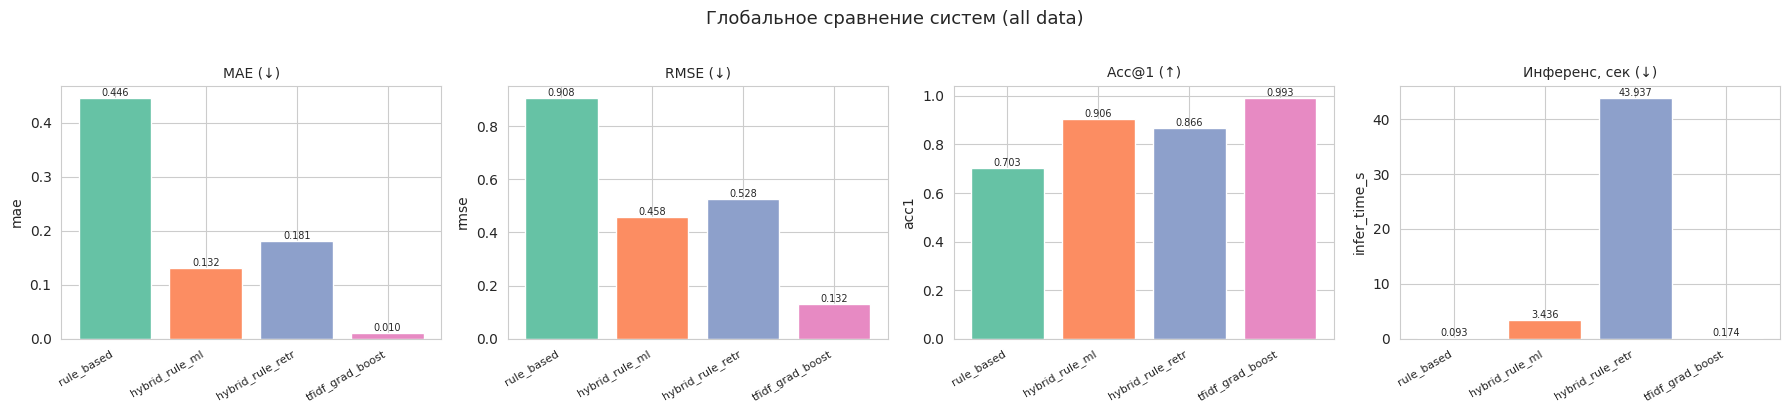

In [ ]:
SYSTEMS  = ["rule_based", "hybrid_rule_ml", "hybrid_rule_retr", f"tfidf_{best_model_name}"]
PALETTE  = dict(zip(SYSTEMS, sns.color_palette("Set2", len(SYSTEMS))))

def bar_chart(ax, data_series, title, ylabel, annotate=True):
    colors = [PALETTE.get(i, "#888") for i in data_series.index]
    bars = ax.bar(range(len(data_series)), data_series.values, color=colors, edgecolor="white")
    ax.set_title(title, fontsize=10)
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(len(data_series)))
    ax.set_xticklabels(data_series.index, rotation=30, ha="right", fontsize=8)
    if annotate:
        for bar, v in zip(bars, data_series.values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                    f"{v:.3f}", ha="center", va="bottom", fontsize=7)


fig, axes = plt.subplots(1, 4, figsize=(18, 4))
gs_df = global_summary.set_index("system").reindex(SYSTEMS)

for ax, col, title in zip(
    axes,
    ["mae","rmse","acc1","infer_time_s"],
    ["MAE (↓)","RMSE (↓)","Acc@1 (↑)","Инференс, сек (↓)"]
):
    bar_chart(ax, gs_df[col], title, col)

plt.suptitle("Глобальное сравнение систем (all data)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

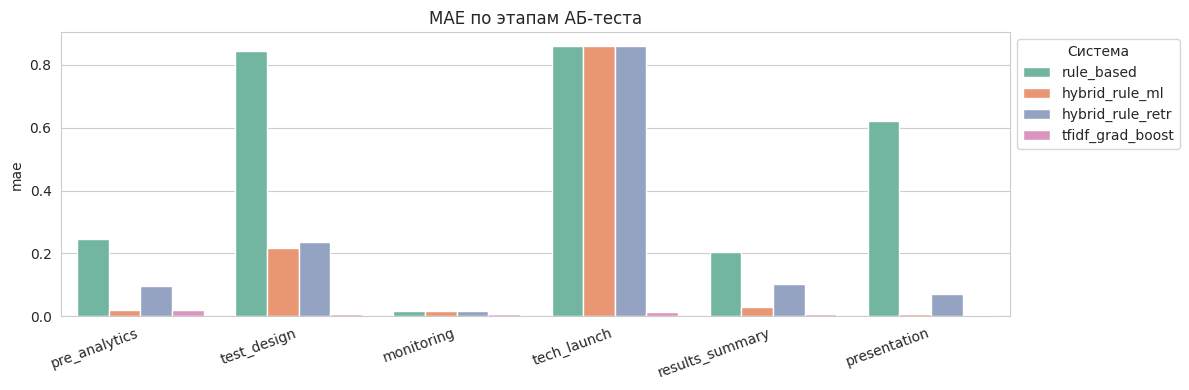

In [ ]:
# MAE по этапам
stage_melt = stage_mae_all.reset_index().melt(id_vars="stage", var_name="system", value_name="mae")

plt.figure(figsize=(12, 4))
ax = sns.barplot(data=stage_melt, x="stage", y="mae", hue="system",
                 palette=[PALETTE[s] for s in SYSTEMS])
plt.title("MAE по этапам АБ-теста", fontsize=12)
plt.xlabel("")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Система", bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()

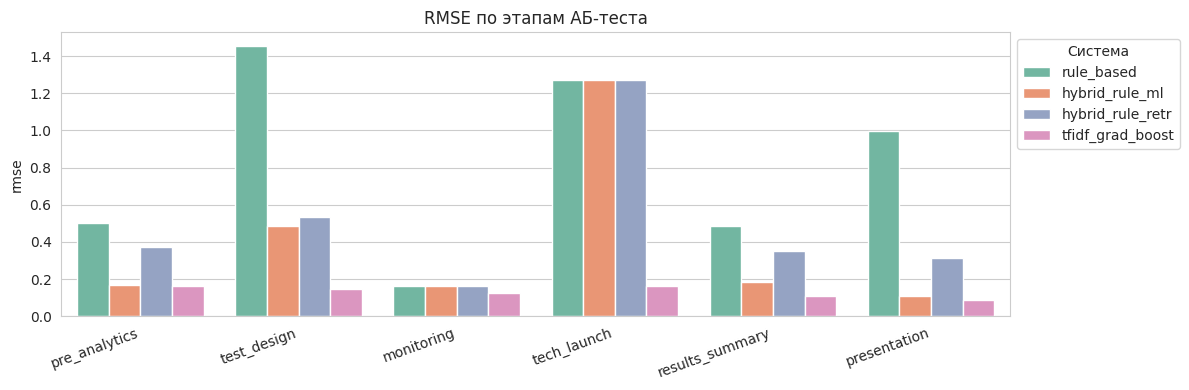

In [ ]:
# RMSE по этапам
stage_rmse_all = pd.DataFrame({
    "rule_based":          stage_rule["rmse"],
    "hybrid_rule_ml":      stage_hybrid["rmse"],
    "hybrid_rule_retr":    stage_retr["rmse"],
    f"tfidf_{best_model_name}": stage_tfidf["rmse"],
}).reindex(STAGE_ORDER).fillna(0)

rmse_melt = stage_rmse_all.reset_index().melt(id_vars="stage", var_name="system", value_name="rmse")

plt.figure(figsize=(12, 4))
sns.barplot(data=rmse_melt, x="stage", y="rmse", hue="system",
            palette=[PALETTE[s] for s in SYSTEMS])
plt.title("RMSE по этапам АБ-теста", fontsize=12)
plt.xlabel("")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Система", bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()


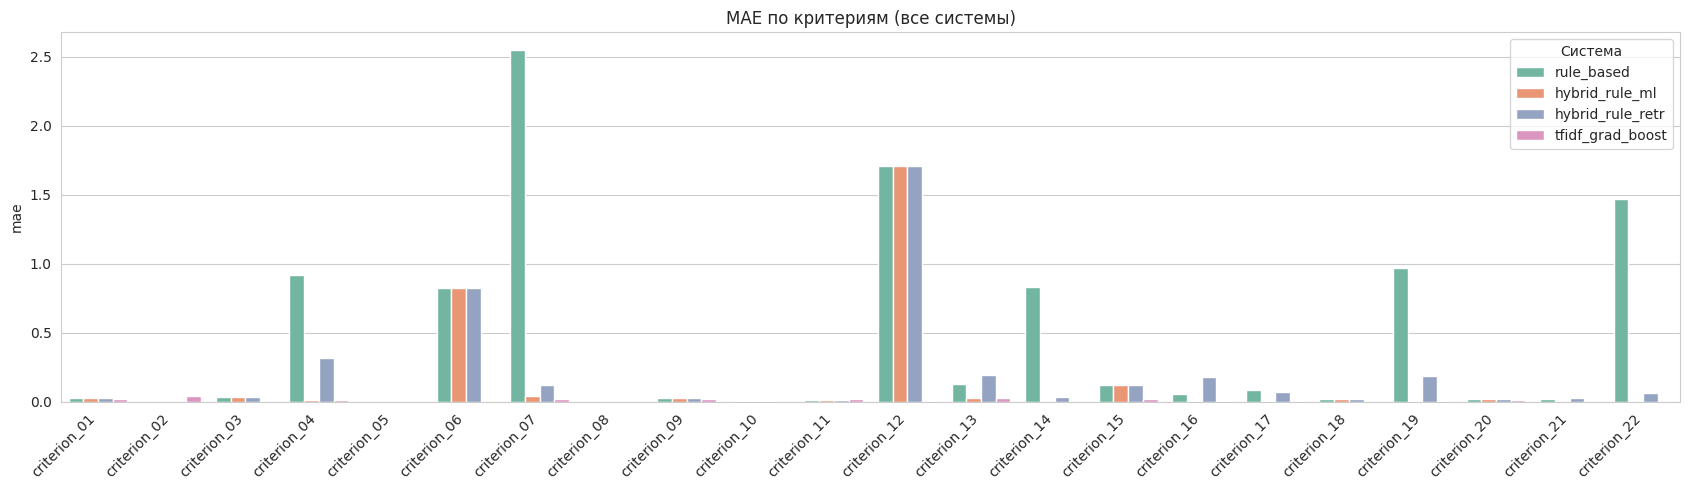

In [ ]:
# ── 4. MAE по критериям ─────────────────────────────────────────────────────
crit_mae_melt = crit_mae_all.reset_index().melt(
    id_vars="criterion", var_name="system", value_name="mae")

plt.figure(figsize=(17, 5))
sns.barplot(data=crit_mae_melt, x="criterion", y="mae", hue="system",
            palette=[PALETTE[s] for s in SYSTEMS])
plt.title("MAE по критериям (все системы)", fontsize=12)
plt.xlabel("")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Система", bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()

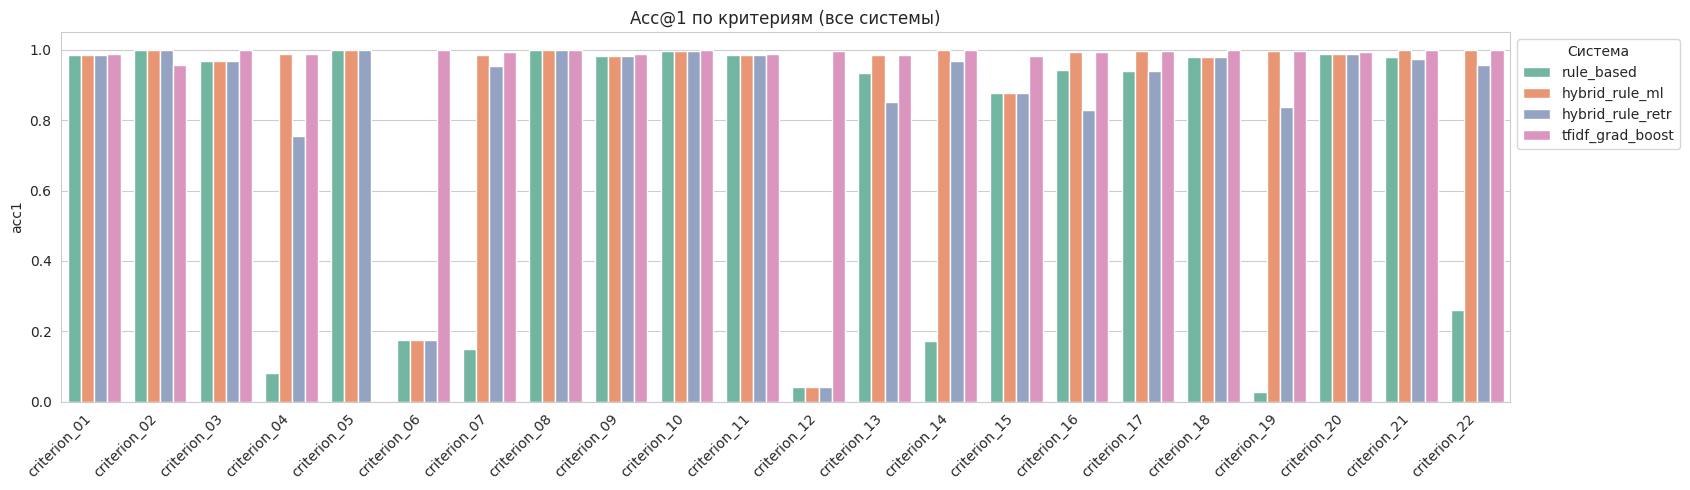

In [ ]:
# ── 5. Acc@1 по критериям ───────────────────────────────────────────────────
crit_acc_all = pd.DataFrame({
    "rule_based":          crit_rule["acc1"],
    "hybrid_rule_ml":      crit_hybrid["acc1"],
    "hybrid_rule_retr":    crit_retr["acc1"],
    f"tfidf_{best_model_name}": crit_tfidf["acc1"],
}).reindex(ALL_CRITERIA).fillna(0)

acc_melt = crit_acc_all.reset_index().melt(
    id_vars="criterion", var_name="system", value_name="acc1")

plt.figure(figsize=(17, 5))
sns.barplot(data=acc_melt, x="criterion", y="acc1", hue="system",
            palette=[PALETTE[s] for s in SYSTEMS])
plt.title("Acc@1 по критериям (все системы)", fontsize=12)
plt.xlabel("")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Система", bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()

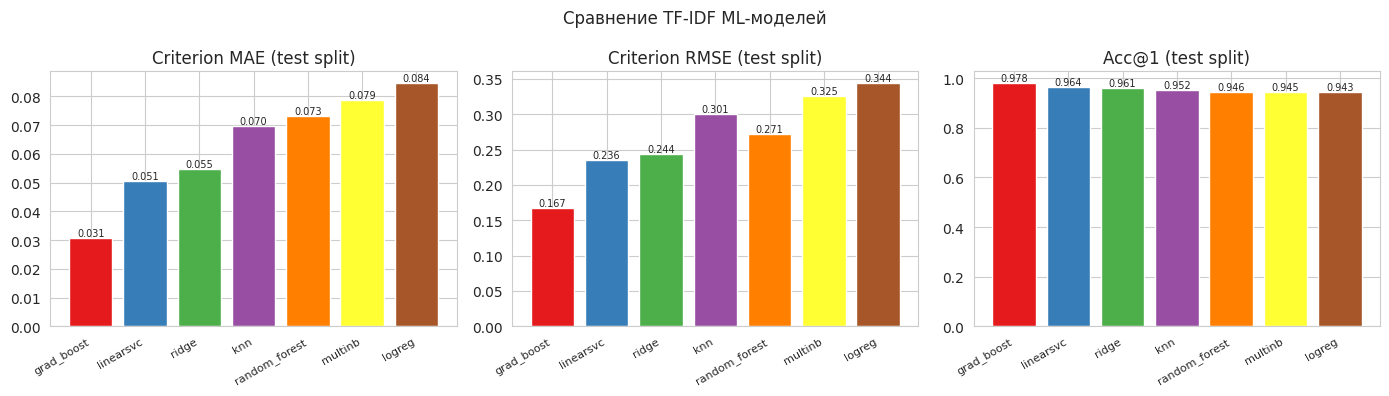

In [ ]:
# TF-IDF ML-модели сравнение
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
pal = sns.color_palette("Set1", len(ML_MODELS))

for ax, col, title in zip(
    axes,
    ["mae","rmse","acc1"],
    ["Criterion MAE (test split)","Criterion RMSE (test split)","Acc@1 (test split)"]
):
    bars = ax.bar(summary_ml["model"], summary_ml[col], color=pal, edgecolor="white")
    ax.set_title(title)
    ax.set_xticklabels(summary_ml["model"], rotation=30, ha="right", fontsize=8)
    for bar, v in zip(bars, summary_ml[col]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(),
                f"{v:.3f}", ha="center", va="bottom", fontsize=7)

plt.suptitle("Сравнение TF-IDF ML-моделей", fontsize=12)
plt.tight_layout()
plt.show()


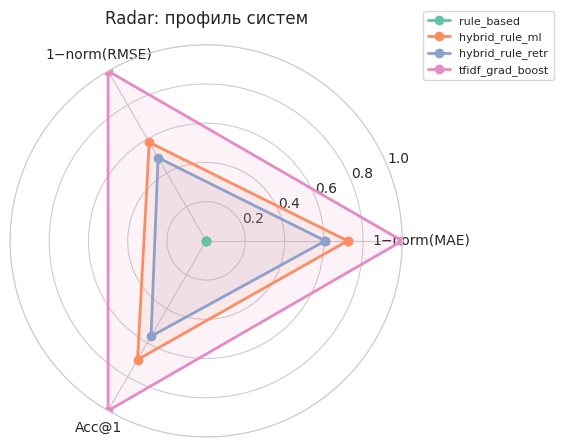

In [ ]:
# Radar chart
radar_metrics = ["mae","rmse","acc1"]
labels_r = ["1−norm(MAE)","1−norm(RMSE)","Acc@1"]
gs_r = global_summary.set_index("system").reindex(SYSTEMS)[radar_metrics].copy()

# Нормализуем: mae/rmse → 1-norm (инвертируем), acc1 → norm
for c in ["mae","rmse"]:
    mn, mx = gs_r[c].min(), gs_r[c].max()
    gs_r[c] = 1 - (gs_r[c]-mn)/(mx-mn+1e-9)
for c in ["acc1"]:
    mn, mx = gs_r[c].min(), gs_r[c].max()
    gs_r[c] = (gs_r[c]-mn)/(mx-mn+1e-9)

angles = np.linspace(0, 2*np.pi, len(radar_metrics), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))
for sys_ in SYSTEMS:
    vals_ = gs_r.loc[sys_, radar_metrics].tolist() + [gs_r.loc[sys_, radar_metrics[0]]]
    ax.plot(angles, vals_, "o-", linewidth=2, label=sys_, color=PALETTE[sys_])
    ax.fill(angles, vals_, alpha=0.10, color=PALETTE[sys_])

ax.set_thetagrids(np.degrees(angles[:-1]), labels_r)
ax.set_ylim(0,1)
ax.set_title("Radar: профиль систем", pad=15)
ax.legend(loc="upper right", bbox_to_anchor=(1.4,1.1), fontsize=8)
plt.tight_layout()
plt.show()


#### Экспорт результатов

In [ ]:
with pd.ExcelWriter(SUMMARY_XLSX, engine="openpyxl") as writer:
    global_summary.to_excel(writer,  sheet_name="global_summary",  index=False)
    stage_mae_all.to_excel(writer,   sheet_name="stage_mae")
    stage_rmse_all.to_excel(writer,  sheet_name="stage_rmse")
    crit_mae_all.to_excel(writer,    sheet_name="criterion_mae")
    crit_acc_all.to_excel(writer,    sheet_name="criterion_acc1")
    rule_eval.to_excel(writer,       sheet_name="eval_rule",       index=False)
    hybrid_eval.to_excel(writer,     sheet_name="eval_hybrid_ml",  index=False)
    retr_eval.to_excel(writer,       sheet_name="eval_hybrid_retr",index=False)

with pd.ExcelWriter(ML_XLSX, engine="openpyxl") as writer:
    ml_metrics.to_excel(writer,      sheet_name="per_criterion",   index=False)
    summary_ml.to_excel(writer,      sheet_name="model_summary",   index=False)
    best_per_crit.to_excel(writer,   sheet_name="best_per_crit",   index=False)

# Артефакты
joblib.dump(tfidf, MODELS_DIR / "tfidf_vectorizer.pkl")
joblib.dump(trained_models[best_model_name], MODELS_DIR / "criterion_models_best.pkl")

print("Результаты сохранены.")
print(f"Лучшая система по MAE: {global_summary.iloc[0]['system']}")
print(f"Лучшая TF-IDF модель : {best_model_name}")

Результаты сохранены.
Лучшая система по MAE: tfidf_grad_boost
Лучшая TF-IDF модель : grad_boost
